# Data Vis: Visualizing Numerical and Categorical Data
* Notebook 1: Data Preparation

## Setup

In [1]:
import pandas as pd
import numpy as np
import missingno as msno

# Data

In this notebook, we will use the NYC Flights 2013 dataset, which contains information about all domestic flights that departed from NYC in 2013. The dataset includes the following tables:
- `flights`: Contains information about each flight, including the origin and destination airports, departure and arrival times, and delays.
- `planes`: Contains information about the planes, including their tail numbers and model years.
- `airports`: Contains information about the airports, including their names and locations.
- `airlines`: Contains information about the airlines, including their names and IATA codes.
- `weather`: Contains information about the weather at the origin airports, including temperature, wind speed, and precipitation.

The dataset is available in the `nycflights13` package.

In [3]:
from nycflights13 import flights
from nycflights13 import planes
from nycflights13 import airports
from nycflights13 import airlines
from nycflights13 import weather

Let's first look at the main table, that is, `flights`.

In [4]:
flights.head()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01T10:00:00Z
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01T10:00:00Z
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01T10:00:00Z
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01T10:00:00Z
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01T11:00:00Z


Next, we will explore the `planes` table. We rename the `year` column to avoid naming conflicts when joining the tables with others.

In [5]:
planes.rename(columns={'year': 'year_built'}, inplace=True)
planes

,tailnum,year_built,type,manufacturer,model,engines,seats,speed,engine
0,N10156,2004.0,Fixed wing multi engine,EMBRAER,EMB-145XR,2,55,NaN,Turbo-fan
1,N102UW,1998.0,Fixed wing multi engine,AIRBUS INDUSTRIE,A320-214,2,182,NaN,Turbo-fan
2,N103US,1999.0,Fixed wing multi engine,AIRBUS INDUSTRIE,A320-214,2,182,NaN,Turbo-fan
3,N104UW,1999.0,Fixed wing multi engine,AIRBUS INDUSTRIE,A320-214,2,182,NaN,Turbo-fan
4,N10575,2002.0,Fixed wing multi engine,EMBRAER,EMB-145LR,2,55,NaN,Turbo-fan
...,...,...,...,...,...,...,...,...,...
3317,N997AT,2002.0,Fixed wing multi engine,BOEING,717-200,2,100,NaN,Turbo-fan
3318,N997DL,1992.0,Fixed wing multi engine,MCDONNELL DOUGLAS AIRCRAFT CO,MD-88,2,142,NaN,Turbo-fan
3319,N998AT,2002.0,Fixed wing multi engine,BOEING,717-200,2,100,NaN,Turbo-fan
3320,N998DL,1992.0,Fixed wing multi engine,MCDONNELL DOUGLAS CORPORATION,MD-88,2,142,NaN,Turbo-jet


We do the same for the `airports`, `airlines`, and `weather` tables.

In [6]:
airports.rename(columns={'name': 'airport_name'}, inplace=True)
airports.head()

,faa,airport_name,lat,lon,alt,tz,dst,tzone
0,04G,Lansdowne Airport,41.130472,-80.619583,1044,-5,A,America/New_York
1,06A,Moton Field Municipal Airport,32.460572,-85.680028,264,-6,A,America/Chicago
2,06C,Schaumburg Regional,41.989341,-88.101243,801,-6,A,America/Chicago
3,06N,Randall Airport,41.431912,-74.391561,523,-5,A,America/New_York
4,09J,Jekyll Island Airport,31.074472,-81.427778,11,-5,A,America/New_York


In [7]:
airlines.rename(columns={'name': 'airline_name'}, inplace=True)
airlines.head()

,carrier,airline_name
0,9E,Endeavor Air Inc.
1,AA,American Airlines Inc.
2,AS,Alaska Airlines Inc.
3,B6,JetBlue Airways
4,DL,Delta Air Lines Inc.


In [8]:
weather.drop(columns=['time_hour'], inplace=True)
weather.head()

,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib
0,EWR,2013,1,1,1,39.02,26.06,59.37,270.0,10.35702,NaN,0.0,1012.0,10.0
1,EWR,2013,1,1,2,39.02,26.96,61.63,250.0,8.05546,NaN,0.0,1012.3,10.0
2,EWR,2013,1,1,3,39.02,28.04,64.43,240.0,11.50780,NaN,0.0,1012.5,10.0
3,EWR,2013,1,1,4,39.92,28.04,62.21,250.0,12.65858,NaN,0.0,1012.2,10.0
4,EWR,2013,1,1,5,39.02,28.04,64.43,260.0,12.65858,NaN,0.0,1011.9,10.0


Let's now join the tables together. We use `left joins`, indicate the columns to join on (both in the left and right tables), and specify the suffixes for the columns with naming conflicts.

In [9]:
flights_joined = flights.merge(airlines, how='left', on='carrier')
flights_joined = flights_joined.merge(planes, how='left', on='tailnum', suffixes=('', '_plane'))
flights_joined = flights_joined.merge(airports, how='left', left_on='origin', right_on='faa', suffixes=('_dest', '_origin'))
flights_joined = flights_joined.merge(airports, how='left', left_on='dest', right_on='faa', suffixes=('_origin', '_dest'))
flights_joined = flights_joined.merge(weather, how='left', left_on=['origin', 'year', 'month', 'day', 'hour'], right_on=['origin', 'year', 'month', 'day', 'hour'], suffixes=('', '_weather'))


Check the shape of the original `flights` table and the joined table. The joined table should have more columns than the original `flights` table, but the same number of rows.

In [10]:
flights.shape

(336776, 19)

In [11]:
flights_joined.shape

(336776, 53)

In [12]:
flights_joined.head(20)

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,...,tzone_dest,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,...,America/Chicago,39.02,28.04,64.43,260.0,12.65858,NaN,0.0,1011.9,10.0
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,...,America/Chicago,39.92,24.98,54.81,250.0,14.96014,21.86482,0.0,1011.4,10.0
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,...,America/New_York,39.02,26.96,61.63,260.0,14.96014,NaN,0.0,1012.1,10.0
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,...,NaN,39.02,26.96,61.63,260.0,14.96014,NaN,0.0,1012.1,10.0
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,...,America/New_York,39.92,24.98,54.81,260.0,16.11092,23.01560,0.0,1011.7,10.0
5,2013,1,1,554.0,558,-4.0,740.0,728,12.0,UA,...,America/Chicago,39.02,28.04,64.43,260.0,12.65858,NaN,0.0,1011.9,10.0
6,2013,1,1,555.0,600,-5.0,913.0,854,19.0,B6,...,America/New_York,37.94,28.04,67.21,240.0,11.50780,NaN,0.0,1012.4,10.0
7,2013,1,1,557.0,600,-3.0,709.0,723,-14.0,EV,...,America/New_York,39.92,24.98,54.81,260.0,16.11092,23.01560,0.0,1011.7,10.0
8,2013,1,1,557.0,600,-3.0,838.0,846,-8.0,B6,...,America/New_York,37.94,26.96,64.29,260.0,13.80936,NaN,0.0,1012.6,10.0
9,2013,1,1,558.0,600,-2.0,753.0,745,8.0,AA,...,America/Chicago,39.92,24.98,54.81,260.0,16.11092,23.01560,0.0,1011.7,10.0


In [14]:
flights_joined.columns

Index(['year', 'month', 'day', 'dep_time', 'sched_dep_time', 'dep_delay',
       'arr_time', 'sched_arr_time', 'arr_delay', 'carrier', 'flight',
       'tailnum', 'origin', 'dest', 'air_time', 'distance', 'hour', 'minute',
       'time_hour', 'airline_name', 'year_built', 'type', 'manufacturer',
       'model', 'engines', 'seats', 'speed', 'engine', 'faa_origin',
       'airport_name_origin', 'lat_origin', 'lon_origin', 'alt_origin',
       'tz_origin', 'dst_origin', 'tzone_origin', 'faa_dest',
       'airport_name_dest', 'lat_dest', 'lon_dest', 'alt_dest', 'tz_dest',
       'dst_dest', 'tzone_dest', 'temp', 'dewp', 'humid', 'wind_dir',
       'wind_speed', 'wind_gust', 'precip', 'pressure', 'visib'],
      dtype='object')

Use thew `missingno` package to visualize the missing values in the joined table.

<Axes: >

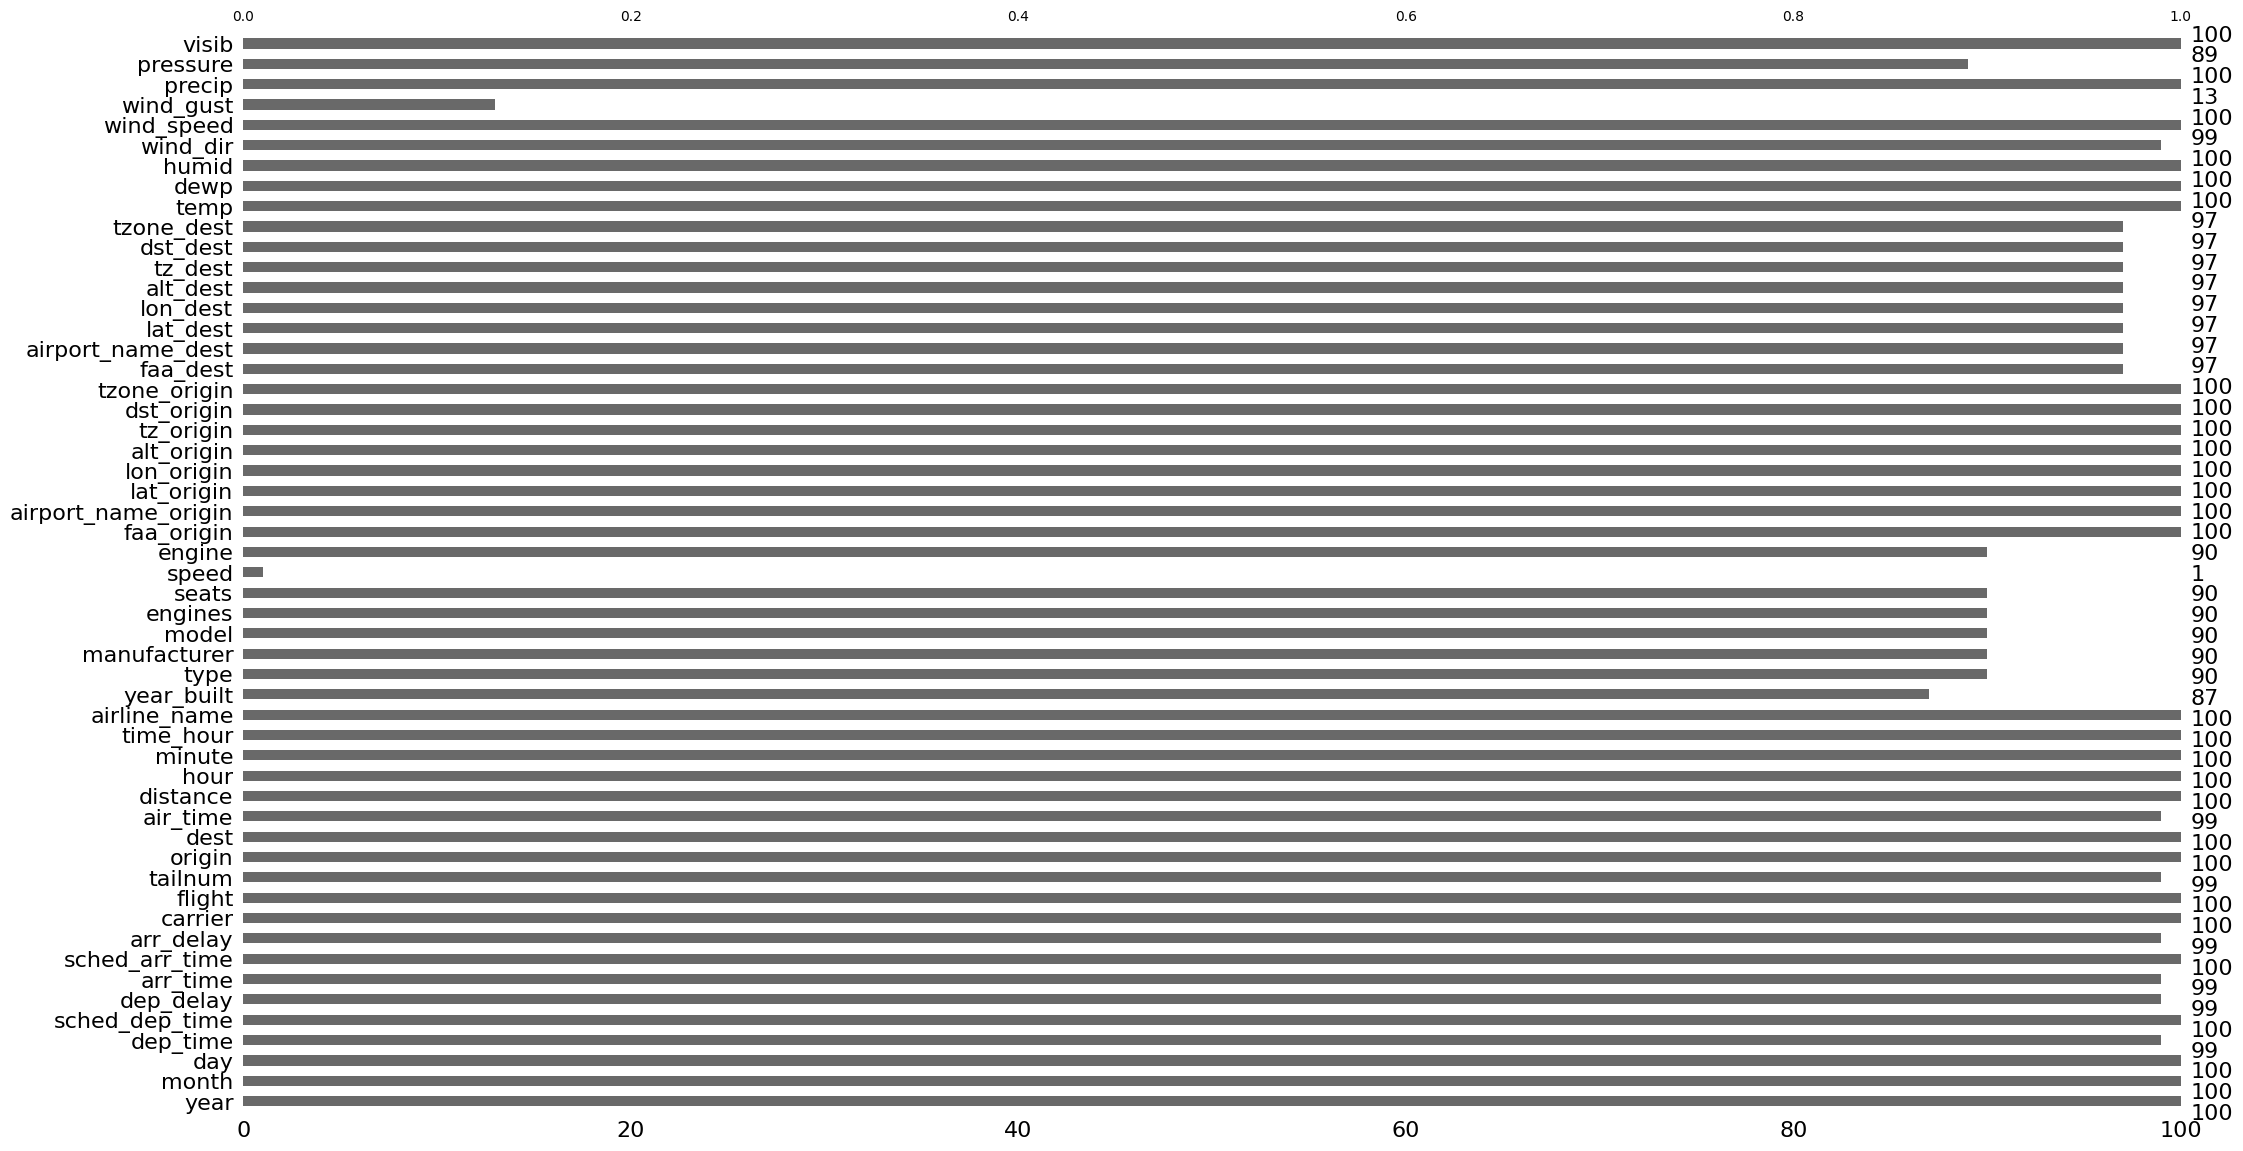

In [17]:
msno.bar(flights_joined.sample(100))

Export joined data to a CSV file for later use.

In [18]:
flights_joined.to_csv('flights_joined.csv', index=False)